In [23]:
import numpy as np
porcentaje=0.3

def sample_image(image, num_beams=int(porcentaje*469), num_pixels_per_beam=int(porcentaje*348)):
    sampled_image = np.zeros_like(image, dtype=float)
    rows, cols = image.shape
    beam_spacing = rows // num_beams
    pixel_spacing = cols // num_pixels_per_beam

    for i in range(0, rows, beam_spacing):
        for j in range(0, cols, pixel_spacing):
            sampled_image[i, j] = image[i, j]
    
    return sampled_image



def add_speckle_noise(image, a=10, b=12, sigma=0.5):
    noisy_image = np.zeros_like(image, dtype=float)
    rows, cols = image.shape
    
    for x in range(rows):
        for y in range(cols):
            if image[x, y] > 0:
                real_part = np.sqrt(image[x, y])
                imag_part = 0

                num_phasors = np.random.randint(a, b)
                for _ in range(num_phasors):
                    u, v = np.random.normal(0, sigma, 2)
                    real_part += u
                    imag_part += v

                noisy_image[x, y] = real_part**2 + imag_part**2  # Evita valores demasiado bajos
                
    return noisy_image



import cv2
def interpolate_image(sampled_image):
    rows, cols = sampled_image.shape
    interpolated_image = cv2.resize(sampled_image, (cols, rows), interpolation=cv2.INTER_LANCZOS4)
    # Normalizar la imagen para mejorar la visualización
    interpolated_image = cv2.normalize(interpolated_image, None, 0, 255, cv2.NORM_MINMAX)
    return interpolated_image

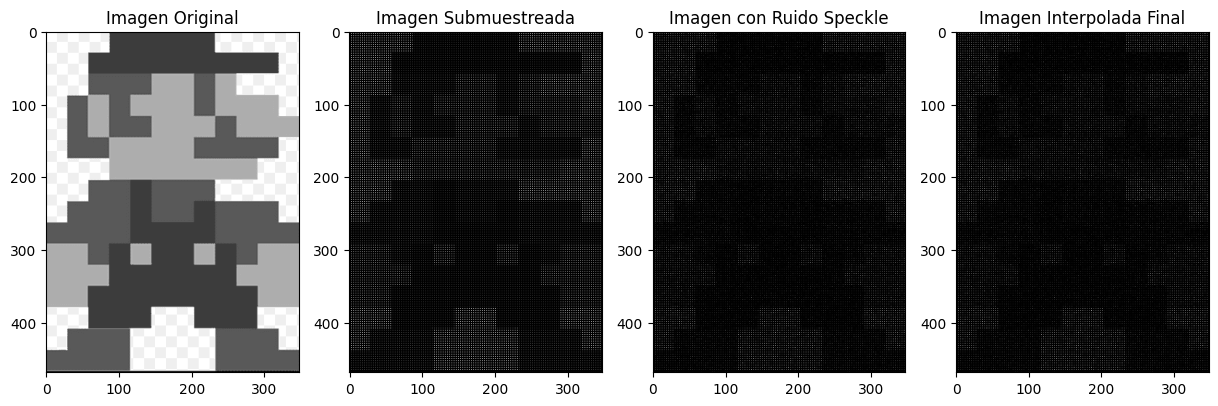

In [24]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen en escala de grises
image = cv2.imread('mario.png', cv2.IMREAD_GRAYSCALE)

# Paso 1: Submuestreo de la imagen
sampled_image = sample_image(image)

# Paso 2: Adición de ruido tipo speckle
noisy_image = add_speckle_noise(sampled_image)

# Paso 3: Interpolación para llenar los huecos
final_image = interpolate_image(noisy_image)

# Mostrar los resultados
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.subplot(1, 4, 2)
plt.title("Imagen Submuestreada")
plt.imshow(sampled_image, cmap='gray')
plt.subplot(1, 4, 3)
plt.title("Imagen con Ruido Speckle")
plt.imshow(noisy_image, cmap='gray')
plt.subplot(1, 4, 4)
plt.title("Imagen Interpolada Final")
plt.imshow(final_image, cmap='gray')
plt.show()


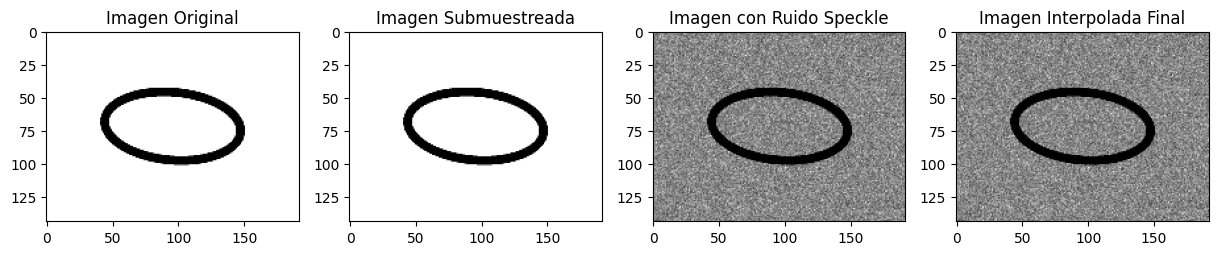

In [55]:
porcentaje=0.7

def sample_image(image, num_beams=int(porcentaje*image.shape[0]), num_pixels_per_beam=int(porcentaje*image.shape[0])):
    sampled_image = np.zeros_like(image, dtype=float)
    rows, cols = image.shape
    beam_spacing = rows // num_beams
    pixel_spacing = cols // num_pixels_per_beam

    for i in range(0, rows, beam_spacing):
        for j in range(0, cols, pixel_spacing):
            sampled_image[i, j] = image[i, j]
    
    return sampled_image

def sample_image(image, porcentaje):
    num_beams=int(porcentaje*image.shape[0])
    num_pixels_per_beam=int(porcentaje*image.shape[0])
    
    sampled_image = np.zeros_like(image, dtype=float)
    rows, cols = image.shape
    beam_spacing = rows // num_beams
    pixel_spacing = cols // num_pixels_per_beam

    for i in range(0, rows, beam_spacing):
        for j in range(0, cols, pixel_spacing):
            sampled_image[i, j] = image[i, j]
    
    return sampled_image


# Cargar imagen en escala de grises
image = cv2.imread('Diastole_000.jpg', cv2.IMREAD_GRAYSCALE)
image=cv2.resize(image, (int(image.shape[1]/4), int(image.shape[0]/4)))

# Paso 1: Submuestreo de la imagen
sampled_image = sample_image(image,porcentaje)

# Paso 2: Adición de ruido tipo speckle
noisy_image = add_speckle_noise(sampled_image)

# Paso 3: Interpolación para llenar los huecos
final_image = interpolate_image(noisy_image)
cv2.imwrite("prueba.jpg",final_image)

# Mostrar los resultados
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.subplot(1, 4, 2)
plt.title("Imagen Submuestreada")
plt.imshow(sampled_image, cmap='gray')
plt.subplot(1, 4, 3)
plt.title("Imagen con Ruido Speckle")
plt.imshow(noisy_image, cmap='gray')
plt.subplot(1, 4, 4)
plt.title("Imagen Interpolada Final")
plt.imshow(final_image, cmap='gray')
plt.show()


36.0